In [31]:
import numpy as np

# Each is [Red, Green, Blue] between 0.0 and 1.0
GRASS = np.array([0.16, 0.34, 0.16], dtype=np.float32)  # Dark green
ROAD  = np.array([0.44, 0.44, 0.46], dtype=np.float32)  # Gray asphalt
KERB  = np.array([0.75, 0.72, 0.62], dtype=np.float32)  # Sandy curb
CAR   = np.array([0.92, 0.20, 0.15], dtype=np.float32)  # Bright red

In [32]:
SIZE = 24
R = 8.0
HALF_W = 2.2

# center coordinate
c = (SIZE - 1) / 2.0
yy, xx = np.mgrid[0:SIZE, 0:SIZE]
rad = np.sqrt((xx - c)**2 + (yy - c)**2)

# Construct canvas
track = np.tile(GRASS, (SIZE, SIZE, 1)).astype(np.float32)
track[np.abs(rad - R) <= HALF_W] = ROAD
track[np.abs(np.abs(rad - R) - HALF_W) <= 0.45] = KERB



In [33]:
print(f"Tensor shape of {track.shape}")
print(f"TOATAL NO.  {track.size}")
print(f"PIXAL COLOR AT : (11,5) {track[11,5]}")
print(f"PIXAL COLOR AT : (11,5) {track[7,5]}")


Tensor shape of (24, 24, 3)
TOATAL NO.  1728
PIXAL COLOR AT : (11,5) [0.44 0.44 0.46]
PIXAL COLOR AT : (11,5) [0.44 0.44 0.46]


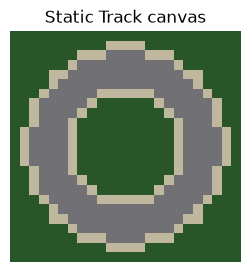

In [34]:
from matplotlib import figure

# Display the tracks
import matplotlib.pyplot as plt
plt.figure(figsize=(3,3))
plt.imshow(track)
plt.title("Static Track canvas")
plt.axis("off")
plt.show()


In [ ]:
self.theta  = self.rng.uniform(0,2 * np.pi)   # angular position around the circle (0 - 2π)

self.d = self.rng.uniform(-1.0,1.0)   # of set from the center line either inside or utside
self.phi = self.rng.uniform(-0.2,0.2)  # Steering angle / heading
self.direction = int(self.rng.choice([-1,1]))




In [ ]:
# From Polar co-ordinates to  cartiesian grid

r = self.R + self.d


# Polar cordinates to cartesian : x  = x = cx + r*cos(θ), y = cy + r*sin(θ)
x = self._c + r * np.cos(self.theta)
y = self._c + r * np.sin(self.theta)

# round to the nearest intger

xi , yi = int(round(x)) , int(round(y))
 




In [ ]:
# painting 2 * 2 red block ( 4 pixals ) centered of ( xi , yi)
CAR = np.array([0.92, 0.20, 0.15], np.float32)  # Red color

img = self.track.copy

for dx in (0, 1):
    for dy in (0, 1):
        px,py = xi + dx - 1 , xy + dy - 1
        # SAFTERY CHECK TO SEE IF CAR IS OUTSIDE THE BOUNDARY
        if 0 <= px <  self.SIZE and 0 <= py < self.SIZE :
            img[py,px] = CAR
return img







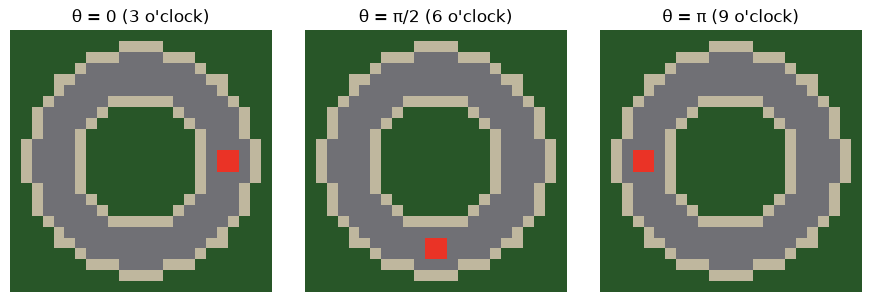

In [35]:
CAR = np.array([0.92, 0.20, 0.15], np.float32)

def place_car(track, theta, d=0.0, R=8.0, c=11.5, size=24):
    img = track.copy()
    # Polar to (x, y) coordinates
    r = R + d
    x = c + r * np.cos(theta)
    y = c + r * np.sin(theta)
    
    xi, yi = int(round(x)), int(round(y))
    
    # Paint 2x2 red square
    for dx in (0, 1):
        for dy in (0, 1):
            px, py = xi + dx - 1, yi + dy - 1
            if 0 <= px < size and 0 <= py < size:
                img[py, px] = CAR
    return img

# Test 3 positions: 0 rad (right), pi/2 rad (bottom), pi rad (left)
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
angles = [0.0, np.pi / 2, np.pi]
labels = ["θ = 0 (3 o'clock)", "θ = π/2 (6 o'clock)", "θ = π (9 o'clock)"]

for ax, th, lbl in zip(axes, angles, labels):
    frame = place_car(track, theta=th, d=0.0)
    ax.imshow(frame)
    ax.set_title(lbl)
    ax.axis("off")

plt.tight_layout()
plt.show()